In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt


import seaborn as sns

from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
tweets_path = "tweets_gobierno_economia.csv"
icc_path = "evolucion_de_la_confianza_del_consumidor_desde_2004.csv"

tweets = pd.read_csv(tweets_path)
icc = pd.read_csv(icc_path, sep=";")

print("Tweets:", tweets.shape)
print("ICC:", icc.shape)

display(tweets.head())
display(icc.head())

Tweets: (11198, 11)
ICC: (267, 3)


,id,fecha,username,contenido,hashtags,tipo,url_media,comentarios,retweets,likes,views
0,2047346501915963634,"Apr 23, 2026 · 4:06 PM UTC",@_minecogob,El sexto desembolso del Plan de Recuperación a...,NaN,Texto simple,NaN,0,30,53,"1,163"
1,2047344028933320813,"Apr 23, 2026 · 3:57 PM UTC",@_minecogob,Gracias a 10.500M€ en préstamos del Plan de Re...,NaN,Texto simple,NaN,11,63,123,"2,778"
2,2047314800384823490,"Apr 23, 2026 · 2:01 PM UTC",@_minecogob,El VP1 @carlos_cuerpo comparece en el @Congres...,NaN,Imagen,https://nitter.net/pic/orig/media%2FHGlw8NnWkA...,2,18,34,727
3,2047231369424588986,"Apr 23, 2026 · 8:29 AM UTC",@carlos_cuerpo,Hablar en el @Congreso_Es de los problemas que...,NaN,Texto simple,NaN,106,414,"1,115","13,674"
4,2047204712961724433,"Apr 23, 2026 · 6:43 AM UTC",@_minecogob,El VP1 @carlos_cuerpo es entrevistado en @LasM...,NaN,Imagen,https://nitter.net/pic/orig/media%2FHGkh1iuXkA...,0,0,1,207


,Año,Periodo,Confianza del consumidor
0,2004,Septiembre,"96,69"
1,2004,Octubre,"90,64"
2,2004,Noviembre,"90,05"
3,2004,Diciembre,"92,11"
4,2005,Enero,"98,03"


In [3]:
# Preparar fechas de los tweets

tweets["fecha_limpia"] = (
    tweets["fecha"]
    .astype(str)
    .str.replace(" · ", " ", regex=False)
    .str.replace(" UTC", "", regex=False)
)

tweets["fecha_dt"] = pd.to_datetime(
    tweets["fecha_limpia"],
    format="%b %d, %Y %I:%M %p",
    errors="coerce"
)

print("Fechas nulas:", tweets["fecha_dt"].isna().sum())
print("Fecha mínima:", tweets["fecha_dt"].min())
print("Fecha máxima:", tweets["fecha_dt"].max())

tweets["mes"] = tweets["fecha_dt"].dt.to_period("M").dt.to_timestamp()

Fechas nulas: 0
Fecha mínima: 2012-02-17 12:46:00
Fecha máxima: 2026-04-23 16:06:00


In [4]:
def limpiar_texto(texto):
    texto = str(texto)
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)   # eliminar enlaces
    texto = re.sub(r"@\w+", " ", texto)               # eliminar menciones
    texto = re.sub(r"#", "", texto)                   # quitar símbolo hashtag
    texto = re.sub(r"\n", " ", texto)                 # saltos de línea
    texto = re.sub(r"\s+", " ", texto).strip()        # espacios extra
    return texto

tweets["texto_limpio"] = tweets["contenido"].apply(limpiar_texto)

display(tweets[["fecha", "username", "contenido", "texto_limpio"]].head())

,fecha,username,contenido,texto_limpio
0,"Apr 23, 2026 · 4:06 PM UTC",@_minecogob,El sexto desembolso del Plan de Recuperación a...,El sexto desembolso del Plan de Recuperación a...
1,"Apr 23, 2026 · 3:57 PM UTC",@_minecogob,Gracias a 10.500M€ en préstamos del Plan de Re...,Gracias a 10.500M€ en préstamos del Plan de Re...
2,"Apr 23, 2026 · 2:01 PM UTC",@_minecogob,El VP1 @carlos_cuerpo comparece en el @Congres...,El VP1 comparece en el para dar cuenta de los ...
3,"Apr 23, 2026 · 8:29 AM UTC",@carlos_cuerpo,Hablar en el @Congreso_Es de los problemas que...,Hablar en el de los problemas que realmente pr...
4,"Apr 23, 2026 · 6:43 AM UTC",@_minecogob,El VP1 @carlos_cuerpo es entrevistado en @LasM...,El VP1 es entrevistado en . ⏰A partir de las 0...


In [5]:
def calcular_polaridad(texto):
    try:
        return TextBlob(str(texto)).sentiment.polarity
    except:
        return np.nan

tweets["polaridad"] = tweets["texto_limpio"].apply(calcular_polaridad)

tweets["sentimiento_positivo"] = (tweets["polaridad"] > 0.05).astype(int)
tweets["sentimiento_negativo"] = (tweets["polaridad"] < -0.05).astype(int)
tweets["sentimiento_neutro"] = (
    (tweets["polaridad"] >= -0.05) & (tweets["polaridad"] <= 0.05)
).astype(int)

display(tweets[["texto_limpio", "polaridad", "sentimiento_positivo", "sentimiento_negativo"]].head())

,texto_limpio,polaridad,sentimiento_positivo,sentimiento_negativo
0,El sexto desembolso del Plan de Recuperación a...,0.0,0,0
1,Gracias a 10.500M€ en préstamos del Plan de Re...,0.0,0,0
2,El VP1 comparece en el para dar cuenta de los ...,0.0,0,0
3,Hablar en el de los problemas que realmente pr...,0.0,0,0
4,El VP1 es entrevistado en . ⏰A partir de las 0...,0.0,0,0


In [6]:
sentimiento_mensual = tweets.groupby("mes").agg(
    volumen_publicaciones=("id", "count"),
    polaridad_media=("polaridad", "mean"),
    polaridad_mediana=("polaridad", "median"),
    proporcion_positivas=("sentimiento_positivo", "mean"),
    proporcion_negativas=("sentimiento_negativo", "mean"),
    proporcion_neutras=("sentimiento_neutro", "mean")
).reset_index()

display(sentimiento_mensual.head())
display(sentimiento_mensual.tail())

print("Meses con tweets:", sentimiento_mensual.shape[0])

,mes,volumen_publicaciones,polaridad_media,polaridad_mediana,proporcion_positivas,proporcion_negativas,proporcion_neutras
0,2012-02-01,7,0.002381,0.0,0.000,0.0,1.000
1,2012-03-01,8,0.025000,0.0,0.125,0.0,0.875
2,2012-04-01,6,0.006944,0.0,0.000,0.0,1.000
3,2012-05-01,8,0.000000,0.0,0.000,0.0,1.000
4,2012-06-01,11,0.000000,0.0,0.000,0.0,1.000


,mes,volumen_publicaciones,polaridad_media,polaridad_mediana,proporcion_positivas,proporcion_negativas,proporcion_neutras
138,2025-12-01,19,-0.019298,0.0,0.052632,0.052632,0.894737
139,2026-01-01,23,-0.054348,0.0,0.043478,0.086957,0.869565
140,2026-02-01,38,0.009649,0.0,0.078947,0.026316,0.894737
141,2026-03-01,41,0.037456,0.0,0.097561,0.000000,0.902439
142,2026-04-01,67,0.012935,0.0,0.089552,0.000000,0.910448


Meses con tweets: 143


In [7]:
icc = icc[pd.to_numeric(icc["Año"], errors="coerce").notna()].copy()
icc["Año"] = icc["Año"].astype(int)

meses = {
    "Enero": 1,
    "Febrero": 2,
    "Marzo": 3,
    "Abril": 4,
    "Mayo": 5,
    "Junio": 6,
    "Julio": 7,
    "Agosto": 8,
    "Septiembre": 9,
    "Octubre": 10,
    "Noviembre": 11,
    "Diciembre": 12
}

icc["mes_num"] = icc["Periodo"].map(meses)

icc["fecha_mes"] = pd.to_datetime(
    dict(year=icc["Año"], month=icc["mes_num"], day=1)
)

icc["ICC"] = (
    icc["Confianza del consumidor"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

icc = icc[["fecha_mes", "ICC"]].sort_values("fecha_mes")

display(icc.head())
display(icc.tail())

print("Observaciones ICC:", icc.shape[0])
print("Fecha mínima ICC:", icc["fecha_mes"].min())
print("Fecha máxima ICC:", icc["fecha_mes"].max())

,fecha_mes,ICC
0,2004-09-01,96.69
1,2004-10-01,90.64
2,2004-11-01,90.05
3,2004-12-01,92.11
4,2005-01-01,98.03


,fecha_mes,ICC
248,2025-09-01,81.5
249,2025-10-01,78.7
250,2025-11-01,76.0
251,2025-12-01,75.9
252,2026-01-01,80.5


Observaciones ICC: 253
Fecha mínima ICC: 2004-09-01 00:00:00
Fecha máxima ICC: 2026-01-01 00:00:00


In [8]:
# Merge ICC series with monthly sentiment metrics
# Align on the month (fecha_mes from ICC and mes from sentiment)
# If there are months without tweets, volumen_publicaciones will be NaN (we set to 0)

df = pd.merge(
    icc,
    sentimiento_mensual,
    left_on="fecha_mes",
    right_on="mes",
    how="left",
)

# Fill missing sentiment metrics for months without tweets
sent_cols = [
    "volumen_publicaciones",
    "polaridad_media",
    "polaridad_mediana",
    "proporcion_positivas",
    "proporcion_negativas",
    "proporcion_neutras",
]
for c in sent_cols:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# Keep fecha_mes as the main date column and drop redundant 'mes'
if "mes" in df.columns:
    df = df.drop(columns=["mes"])

# Ensure sorted by date
df = df.sort_values("fecha_mes").reset_index(drop=True)

# Create lag features and target
df["ICC_lag_1"] = df["ICC"].shift(1)
df["ICC_lag_2"] = df["ICC"].shift(2)
df["ICC_lag_3"] = df["ICC"].shift(3)

df["ICC_objetivo_t1"] = df["ICC"].shift(-1)

# Prepare final dataset for modeling
df_modelo = df.dropna().copy()

display(df_modelo.head())
display(df_modelo.tail())

print("Dataset final para modelo:", df_modelo.shape)

,fecha_mes,ICC,volumen_publicaciones,polaridad_media,polaridad_mediana,proporcion_positivas,proporcion_negativas,proporcion_neutras,ICC_lag_1,ICC_lag_2,ICC_lag_3,ICC_objetivo_t1
3,2004-12-01,92.11,0.0,0.0,0.0,0.0,0.0,0.0,90.05,90.64,96.69,98.03
4,2005-01-01,98.03,0.0,0.0,0.0,0.0,0.0,0.0,92.11,90.05,90.64,94.74
5,2005-02-01,94.74,0.0,0.0,0.0,0.0,0.0,0.0,98.03,92.11,90.05,91.99
6,2005-03-01,91.99,0.0,0.0,0.0,0.0,0.0,0.0,94.74,98.03,92.11,90.60
7,2005-04-01,90.60,0.0,0.0,0.0,0.0,0.0,0.0,91.99,94.74,98.03,91.91


,fecha_mes,ICC,volumen_publicaciones,polaridad_media,polaridad_mediana,proporcion_positivas,proporcion_negativas,proporcion_neutras,ICC_lag_1,ICC_lag_2,ICC_lag_3,ICC_objetivo_t1
247,2025-07-01,82.9,53.0,0.011792,0.0,0.056604,0.000000,0.943396,76.1,82.5,76.5,81.5
248,2025-09-01,81.5,38.0,0.007456,0.0,0.052632,0.000000,0.947368,82.9,76.1,82.5,78.7
249,2025-10-01,78.7,46.0,0.027289,0.0,0.130435,0.000000,0.869565,81.5,82.9,76.1,76.0
250,2025-11-01,76.0,39.0,0.010043,0.0,0.051282,0.000000,0.948718,78.7,81.5,82.9,75.9
251,2025-12-01,75.9,19.0,-0.019298,0.0,0.052632,0.052632,0.894737,76.0,78.7,81.5,80.5


Dataset final para modelo: (249, 12)


In [9]:
features_base = [
    "ICC",
    "ICC_lag_1",
    "ICC_lag_2",
    "ICC_lag_3"
]

features_sentimiento = [
    "ICC",
    "ICC_lag_1",
    "ICC_lag_2",
    "ICC_lag_3",
    "volumen_publicaciones",
    "polaridad_media",
    "polaridad_mediana",
    "proporcion_positivas",
    "proporcion_negativas",
    "proporcion_neutras"
]

target = "ICC_objetivo_t1"

In [10]:
df_modelo = df_modelo.sort_values("fecha_mes").reset_index(drop=True)

split_index = int(len(df_modelo) * 0.8)

train = df_modelo.iloc[:split_index]
test = df_modelo.iloc[split_index:]

print("Train:", train["fecha_mes"].min(), "→", train["fecha_mes"].max(), train.shape)
print("Test:", test["fecha_mes"].min(), "→", test["fecha_mes"].max(), test.shape)

X_train_base = train[features_base]
X_test_base = test[features_base]

X_train_sent = train[features_sentimiento]
X_test_sent = test[features_sentimiento]

y_train = train[target]
y_test = test[target]

Train: 2004-12-01 00:00:00 → 2021-06-01 00:00:00 (199, 12)
Test: 2021-07-01 00:00:00 → 2025-12-01 00:00:00 (50, 12)


In [11]:
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    
    # Evitar división por cero en MAPE
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    
    r2 = r2_score(y_real, y_pred)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

In [12]:
modelo_base = LinearRegression()
modelo_base.fit(X_train_base, y_train)

pred_base = modelo_base.predict(X_test_base)

metricas_base = calcular_metricas(y_test, pred_base)
metricas_base

{'MAE': 5.1137989355922535,
 'RMSE': np.float64(7.80719869193089),
 'MAPE': np.float64(7.0739657112859735),
 'R2': 0.4263042231219504}

In [13]:
modelo_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=5,
    min_samples_leaf=3
)

modelo_rf.fit(X_train_sent, y_train)

pred_rf = modelo_rf.predict(X_test_sent)

metricas_rf = calcular_metricas(y_test, pred_rf)
metricas_rf

{'MAE': 5.256273340400635,
 'RMSE': np.float64(8.167103205200053),
 'MAPE': np.float64(7.351215418992344),
 'R2': 0.37219137793840895}

In [14]:
try:
    from xgboost import XGBRegressor
    
    modelo_xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    modelo_xgb.fit(X_train_sent, y_train)
    pred_xgb = modelo_xgb.predict(X_test_sent)
    metricas_xgb = calcular_metricas(y_test, pred_xgb)

except Exception as e:
    print("No se pudo usar XGBoost. Se usará GradientBoostingRegressor.")
    print(e)
    
    modelo_xgb = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    
    modelo_xgb.fit(X_train_sent, y_train)
    pred_xgb = modelo_xgb.predict(X_test_sent)
    metricas_xgb = calcular_metricas(y_test, pred_xgb)

metricas_xgb

No se pudo usar XGBoost. Se usará GradientBoostingRegressor.
No module named 'xgboost'


{'MAE': 6.357183981990462,
 'RMSE': np.float64(8.999699320805199),
 'MAPE': np.float64(8.849056305975658),
 'R2': 0.23766266716302598}

In [15]:
resultados = pd.DataFrame([
    {"Modelo": "Regresión lineal base", **metricas_base},
    {"Modelo": "Random Forest con sentimiento", **metricas_rf},
    {"Modelo": "XGBoost/Gradient Boosting con sentimiento", **metricas_xgb}
])

display(resultados)
resultados.to_csv("resultados_modelos_icc.csv", index=False)

,Modelo,MAE,RMSE,MAPE,R2
0,Regresión lineal base,5.113799,7.807199,7.073966,0.426304
1,Random Forest con sentimiento,5.256273,8.167103,7.351215,0.372191
2,XGBoost/Gradient Boosting con sentimiento,6.357184,8.999699,8.849056,0.237663


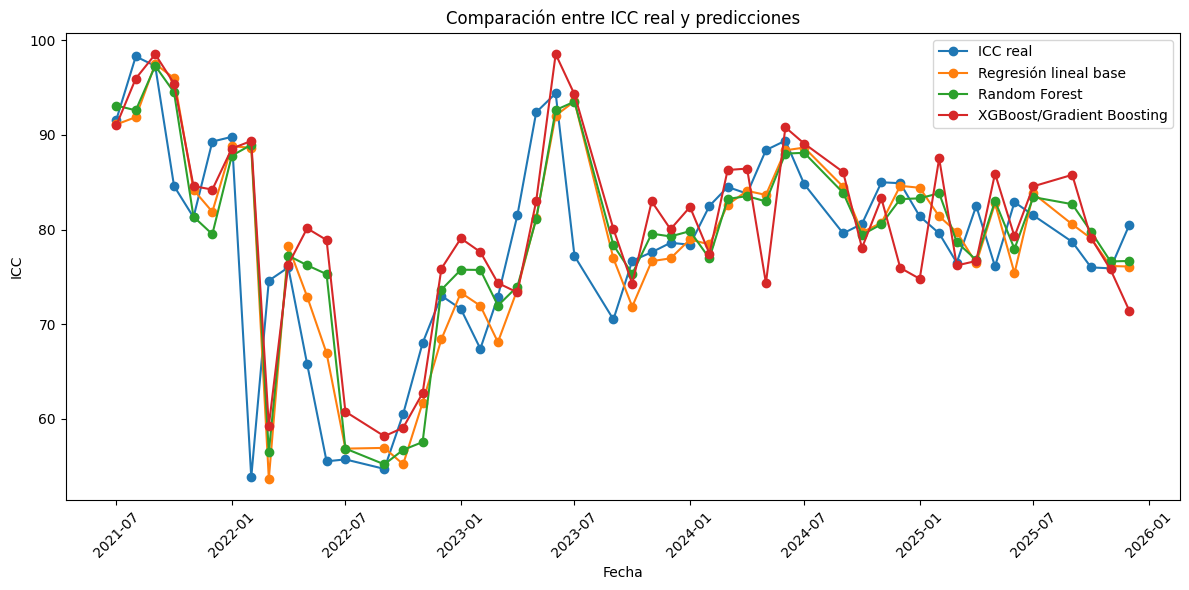

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(test["fecha_mes"], y_test.values, label="ICC real", marker="o")
plt.plot(test["fecha_mes"], pred_base, label="Regresión lineal base", marker="o")
plt.plot(test["fecha_mes"], pred_rf, label="Random Forest", marker="o")
plt.plot(test["fecha_mes"], pred_xgb, label="XGBoost/Gradient Boosting", marker="o")

plt.title("Comparación entre ICC real y predicciones")
plt.xlabel("Fecha")
plt.ylabel("ICC")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Variable,Importancia
0,ICC,0.941998
1,ICC_lag_1,0.016578
2,ICC_lag_2,0.015217
3,ICC_lag_3,0.010369
4,volumen_publicaciones,0.005305
5,polaridad_media,0.004043
9,proporcion_neutras,0.002695
7,proporcion_positivas,0.002044
8,proporcion_negativas,0.001750
6,polaridad_mediana,0.000000


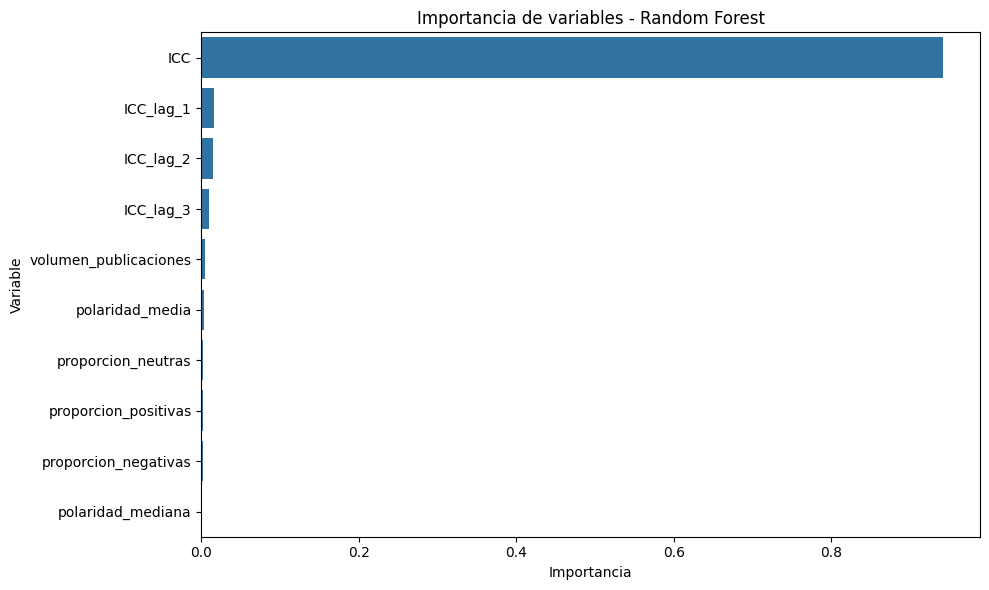

In [17]:
importancias_rf = pd.DataFrame({
    "Variable": features_sentimiento,
    "Importancia": modelo_rf.feature_importances_
}).sort_values("Importancia", ascending=False)

display(importancias_rf)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancias_rf, x="Importancia", y="Variable")
plt.title("Importancia de variables - Random Forest")
plt.tight_layout()
plt.show()

In [18]:
df_modelo.to_csv("dataset_final_icc_sentimiento.csv", index=False)
print("Dataset final guardado correctamente.")

Dataset final guardado correctamente.
